# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 05: Traffic Time-Series Construction (Phase 5)

### Objective & Core Methodology
In Phase 4, we processed 44 highway surveillance clips captured on August 5, 2004, extracting clip-level macroscopic traffic metrics (mean vehicle count per frame, car/truck/bus breakdown, and spatial occupancy ratio via ROI union mask).

In **Phase 5**, we convert these clip-level features into a validated, clean, chronological time-series dataset (`outputs/tables/traffic_timeseries.csv`).

> **CRITICAL METHODOLOGICAL DIRECTIVE**:
> 1. **Discrete Surveillance Sampling**: The dataset consists of **44 discrete sampled clips** (~5.3 seconds each) captured at approximately 4–5 minute intervals spanning 17:00 to 20:00 on August 5, 2004.
> 2. **NO Video Concatenation**: These clips are NOT continuous video and must never be concatenated.
> 3. **NO Synthetic Timestamps**: We preserve the actual sampled observation timestamps ($t_k, k = 1 \dots 44$). We do **NOT** invent regular 30-second or 60-second timestamps.
> 4. **NO Synthetic Interpolation**: We do **NOT** linearly or spline-interpolate missing observations between clips.
> 5. **Scope Guard**: Modeling, normalization, train/test splitting, and forecasting are deferred to subsequent phases. This notebook strictly constructs and validates the empirical time-series dataset for **Phase 6 — Temporal EDA**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib styling for presentation-quality figures
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_clip_features.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
OUTPUT_CSV_PATH = os.path.join(OUTPUT_TAB_DIR, "traffic_timeseries.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

print(f"Project root  : {PROJECT_ROOT}")
print(f"Input features: {INPUT_CSV_PATH}")
print(f"Output table  : {OUTPUT_CSV_PATH}")

Project root  : /Users/manish/Desktop/traffic-flow-yolo-lstm
Input features: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_clip_features.csv
Output table  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv


## 1. Load Phase 4 Feature Matrix & Parse Timestamps

We load the finalized clip-level features from `outputs/tables/traffic_clip_features.csv`.
Each clip represents an empirical observation window with metadata:
- `filename`: format `cctv052x<YYYYMMDD><HH>x<seq_id>.avi`
- `date`: `20040805`
- `timestamp`: formatted observation timestamp string / float from the Seattle CCTV traffic database
- `traffic_class`: ground-truth subjective category (`heavy`, `medium`, `light`)
- `weather`: atmospheric condition (`overcast`, `clear`)

We parse the temporal attributes:
- `hour`: CCTV capture hour (17, 18, 19, 20)
- `seq_id`: CCTV continuous clip sequence number (1652 to 1695)
We ensure strict chronological sorting by `date`, `hour`, and `seq_id`.

In [2]:
# 1. Load the Phase 4 clip feature dataset
df_raw = pd.read_csv(INPUT_CSV_PATH)
print(f"Loaded raw clip features: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# 2. Parse temporal attributes from filename and metadata
df = df_raw.copy()
df['hour'] = df['filename'].apply(lambda x: int(x.split('x')[1][-2:]))
df['seq_id'] = df['filename'].apply(lambda x: int(x.split('x')[-1].replace('.avi', '')))

# Sort chronologically by date and sequence ID
df = df.sort_values(by=['date', 'seq_id']).reset_index(drop=True)
df['observation_index'] = np.arange(1, len(df) + 1)

print(f"Observation count: {len(df)} discrete clips (seq_id {df['seq_id'].min()} to {df['seq_id'].max()})")
display(df[['clip_index', 'observation_index', 'filename', 'timestamp', 'hour', 'seq_id', 'traffic_class', 'weather']].head(8))

Loaded raw clip features: 44 rows, 13 columns
Observation count: 44 discrete clips (seq_id 1652 to 1695)


,clip_index,observation_index,filename,timestamp,hour,seq_id,traffic_class,weather
0,1,1,cctv052x2004080517x01652.avi,17.01652,17,1652,heavy,overcast
1,2,2,cctv052x2004080517x01653.avi,17.01653,17,1653,heavy,overcast
2,3,3,cctv052x2004080517x01654.avi,17.01654,17,1654,heavy,clear
3,4,4,cctv052x2004080517x01655.avi,17.01655,17,1655,heavy,overcast
4,5,5,cctv052x2004080517x01656.avi,17.01656,17,1656,heavy,overcast
5,6,6,cctv052x2004080517x01657.avi,17.01657,17,1657,heavy,overcast
6,7,7,cctv052x2004080517x01658.avi,17.01658,17,1658,heavy,overcast
7,8,8,cctv052x2004080517x01659.avi,17.01659,17,1659,heavy,overcast


## 2. Feature Construction

We construct the standardized time-series features required for macroscopic traffic analysis:

1. **`total_vehicle_count`**:
   The average total number of detected vehicles per frame within the observation clip:
   $$\text{total\_vehicle\_count} = \text{vehicle\_count}$$
   (which represents the sum of cars, trucks, and buses detected in the roadway ROI).

2. **Heavy Vehicle Ratio (`HVR`)**:
   In transportation systems engineering, the Heavy Vehicle Ratio (HVR) quantifies the commercial freight fraction of vehicular flow. We compute it strictly as:
   $$\text{HVR} = \frac{\text{truck\_count}}{\text{car\_count} + \text{truck\_count}}$$
   with safe zero-handling:
   $$\text{HVR} = \begin{cases} \frac{\text{truck\_count}}{\text{car\_count} + \text{truck\_count}}, & \text{if } \text{car\_count} + \text{truck\_count} > 0 \\ 0.0, & \text{otherwise} \end{cases}$$

3. **Spatial Occupancy Ratio (`occupancy_ratio`)**:
   The pixel-level visual occupancy proxy computed from the union mask $\text{Area}\left(\bigcup_i B_i \cap \text{ROI}\right) / \text{Area}(\text{ROI})$ derived in Phase 4.

4. **Retained Contextual Attributes**:
   We preserve all decomposed component metrics (`car_count`, `truck_count`, `bus_count`, `max_occupancy_ratio`, `valid_frames`, `traffic_class`, `weather`, `date`, `hour`, `seq_id`).

In [3]:
# 1. Total vehicle count: directly maps to vehicle_count
df['total_vehicle_count'] = df['vehicle_count']

# 2. Heavy Vehicle Ratio (HVR) with safe zero-division handling
car_truck_sum = df['car_count'] + df['truck_count']
df['HVR'] = np.where(car_truck_sum > 0, df['truck_count'] / car_truck_sum, 0.0).round(4)

# 3. Verify occupancy_ratio integrity (already present from Phase 4)

# Organize columns logically: Identifiers -> Targets -> Decomposed Signals -> Metadata
column_order = [
    'observation_index',
    'clip_index',
    'filename',
    'date',
    'timestamp',
    'hour',
    'seq_id',
    'traffic_class',
    'weather',
    'valid_frames',
    'total_vehicle_count',
    'HVR',
    'occupancy_ratio',
    'car_count',
    'truck_count',
    'bus_count',
    'max_occupancy_ratio'
]

df_timeseries = df[column_order].copy()
print("Constructed time-series features successfully.")
display(df_timeseries[['observation_index', 'filename', 'timestamp', 'total_vehicle_count', 'HVR', 'occupancy_ratio', 'traffic_class']].head(8))

Constructed time-series features successfully.


,observation_index,filename,timestamp,total_vehicle_count,HVR,occupancy_ratio,traffic_class
0,1,cctv052x2004080517x01652.avi,17.01652,8.942,0.0248,0.1492,heavy
1,2,cctv052x2004080517x01653.avi,17.01653,9.558,0.0806,0.2176,heavy
2,3,cctv052x2004080517x01654.avi,17.01654,12.442,0.0032,0.2448,heavy
3,4,cctv052x2004080517x01655.avi,17.01655,12.038,0.0016,0.1483,heavy
4,5,cctv052x2004080517x01656.avi,17.01656,12.269,0.0326,0.2254,heavy
5,6,cctv052x2004080517x01657.avi,17.01657,8.712,0.0628,0.1382,heavy
6,7,cctv052x2004080517x01658.avi,17.01658,12.135,0.0252,0.3008,heavy
7,8,cctv052x2004080517x01659.avi,17.01659,16.192,0.0000,0.2865,heavy


## 3. Comprehensive Time-Series Validation Suite

To ensure the resulting dataset meets all data engineering and scientific requirements before proceeding to Phase 6 (Temporal EDA) and Phase 7 (Modeling), we execute a comprehensive suite of automated validation tests:

1. **Row Count Check**: Exactly 44 discrete observation windows.
2. **Missing Value Check**: Zero null or NaN values across all required and metadata columns.
3. **Duplicate Timestamp Check**: Zero duplicate timestamps.
4. **Strict Chronological Ordering**: Verification that timestamps and sequence IDs are strictly monotonically increasing.
5. **Heavy Vehicle Ratio Bounds**: $\text{HVR} \in [0.0, 1.0]$, finite, and non-negative.
6. **Spatial Occupancy Ratio Bounds**: $\text{occupancy\_ratio} \in [0.0, 1.0]$.
7. **Total Vehicle Count Validity**: $\text{total\_vehicle\_count} \ge 0.0$.
8. **Required Columns Check**: All primary target signals (`timestamp`, `total_vehicle_count`, `HVR`, `occupancy_ratio`) and supporting attributes are present.

In [4]:
# Validation assertions
validation_results = {}

# Test 1: Exactly 44 rows
test_1_pass = len(df_timeseries) == 44
validation_results["1. Exact 44 observation rows"] = "PASS" if test_1_pass else f"FAIL ({len(df_timeseries)} rows)"
assert test_1_pass, f"Expected 44 rows, found {len(df_timeseries)}"

# Test 2: No missing values across any column
missing_counts = df_timeseries.isna().sum().sum()
test_2_pass = missing_counts == 0
validation_results["2. Zero missing / NaN values"] = "PASS" if test_2_pass else f"FAIL ({missing_counts} missing)"
assert test_2_pass, f"Missing values detected: {df_timeseries.isna().sum().to_dict()}"

# Test 3: No duplicate timestamps
dup_timestamps = df_timeseries['timestamp'].duplicated().sum()
test_3_pass = dup_timestamps == 0
validation_results["3. Zero duplicate timestamps"] = "PASS" if test_3_pass else f"FAIL ({dup_timestamps} duplicates)"
assert test_3_pass, f"Found duplicate timestamps: {df_timeseries[df_timeseries['timestamp'].duplicated()]['timestamp'].tolist()}"

# Test 4: Strict chronological ordering
is_sorted = df_timeseries['timestamp'].is_monotonic_increasing and df_timeseries['seq_id'].is_monotonic_increasing
validation_results["4. Strict chronological ordering"] = "PASS" if is_sorted else "FAIL (non-monotonic)"
assert is_sorted, "Dataset is not strictly monotonically increasing in time!"

# Test 5: HVR in [0.0, 1.0], no NaNs or infs
hvr_valid = (
    (df_timeseries['HVR'] >= 0.0).all() and 
    (df_timeseries['HVR'] <= 1.0).all() and 
    not df_timeseries['HVR'].isna().any() and 
    not np.isinf(df_timeseries['HVR']).any()
)
validation_results["5. HVR in [0, 1] & finite"] = "PASS" if hvr_valid else "FAIL"
assert hvr_valid, f"Invalid HVR values: min={df_timeseries['HVR'].min()}, max={df_timeseries['HVR'].max()}"

# Test 6: occupancy_ratio in [0.0, 1.0]
occ_valid = (
    (df_timeseries['occupancy_ratio'] >= 0.0).all() and 
    (df_timeseries['occupancy_ratio'] <= 1.0).all() and 
    not df_timeseries['occupancy_ratio'].isna().any() and 
    not np.isinf(df_timeseries['occupancy_ratio']).any()
)
validation_results["6. Occupancy ratio in [0, 1] & finite"] = "PASS" if occ_valid else "FAIL"
assert occ_valid, f"Invalid occupancy_ratio: min={df_timeseries['occupancy_ratio'].min()}, max={df_timeseries['occupancy_ratio'].max()}"

# Test 7: Required columns present
required_cols = ['timestamp', 'total_vehicle_count', 'HVR', 'occupancy_ratio']
cols_present = all(c in df_timeseries.columns for c in required_cols)
validation_results["7. Required columns present"] = "PASS" if cols_present else "FAIL"
assert cols_present, f"Missing required columns from {required_cols}"

# Print comprehensive validation report
print("=" * 65)
print("             PHASE 5 TIME-SERIES VALIDATION REPORT            ")
print("=" * 65)
for test_name, status in validation_results.items():
    print(f"  [{status:^4}]  {test_name}")
print("=" * 65)
print("ALL 7 VALIDATION CRITERIA SATISFIED.")

             PHASE 5 TIME-SERIES VALIDATION REPORT            
  [PASS]  1. Exact 44 observation rows
  [PASS]  2. Zero missing / NaN values
  [PASS]  3. Zero duplicate timestamps
  [PASS]  4. Strict chronological ordering
  [PASS]  5. HVR in [0, 1] & finite
  [PASS]  6. Occupancy ratio in [0, 1] & finite
  [PASS]  7. Required columns present
ALL 7 VALIDATION CRITERIA SATISFIED.


## 4. Concise Temporal Visualizations

We visualize the macro-level evolution of highway traffic states across the 44 discrete surveillance observations. 

> **Visualizing Discrete Observations**:
> To honor the discrete ~4–5 minute sampling frequency without falsely depicting continuous intermediate states:
> - Individual observation markers (`o`) represent the empirical measurements at each sampled time $t_k$.
> - Dashed transition lines guide the eye across the temporal progression from evening rush hour (17:00) into nighttime free-flow (20:00).
> - Shaded regime bands indicate the subjective traffic density classes: **Heavy** (clips 1–13), **Medium** (clips 14–22), and **Light** (clips 23–44).

Saved overview visualization to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/traffic_timeseries_overview.png


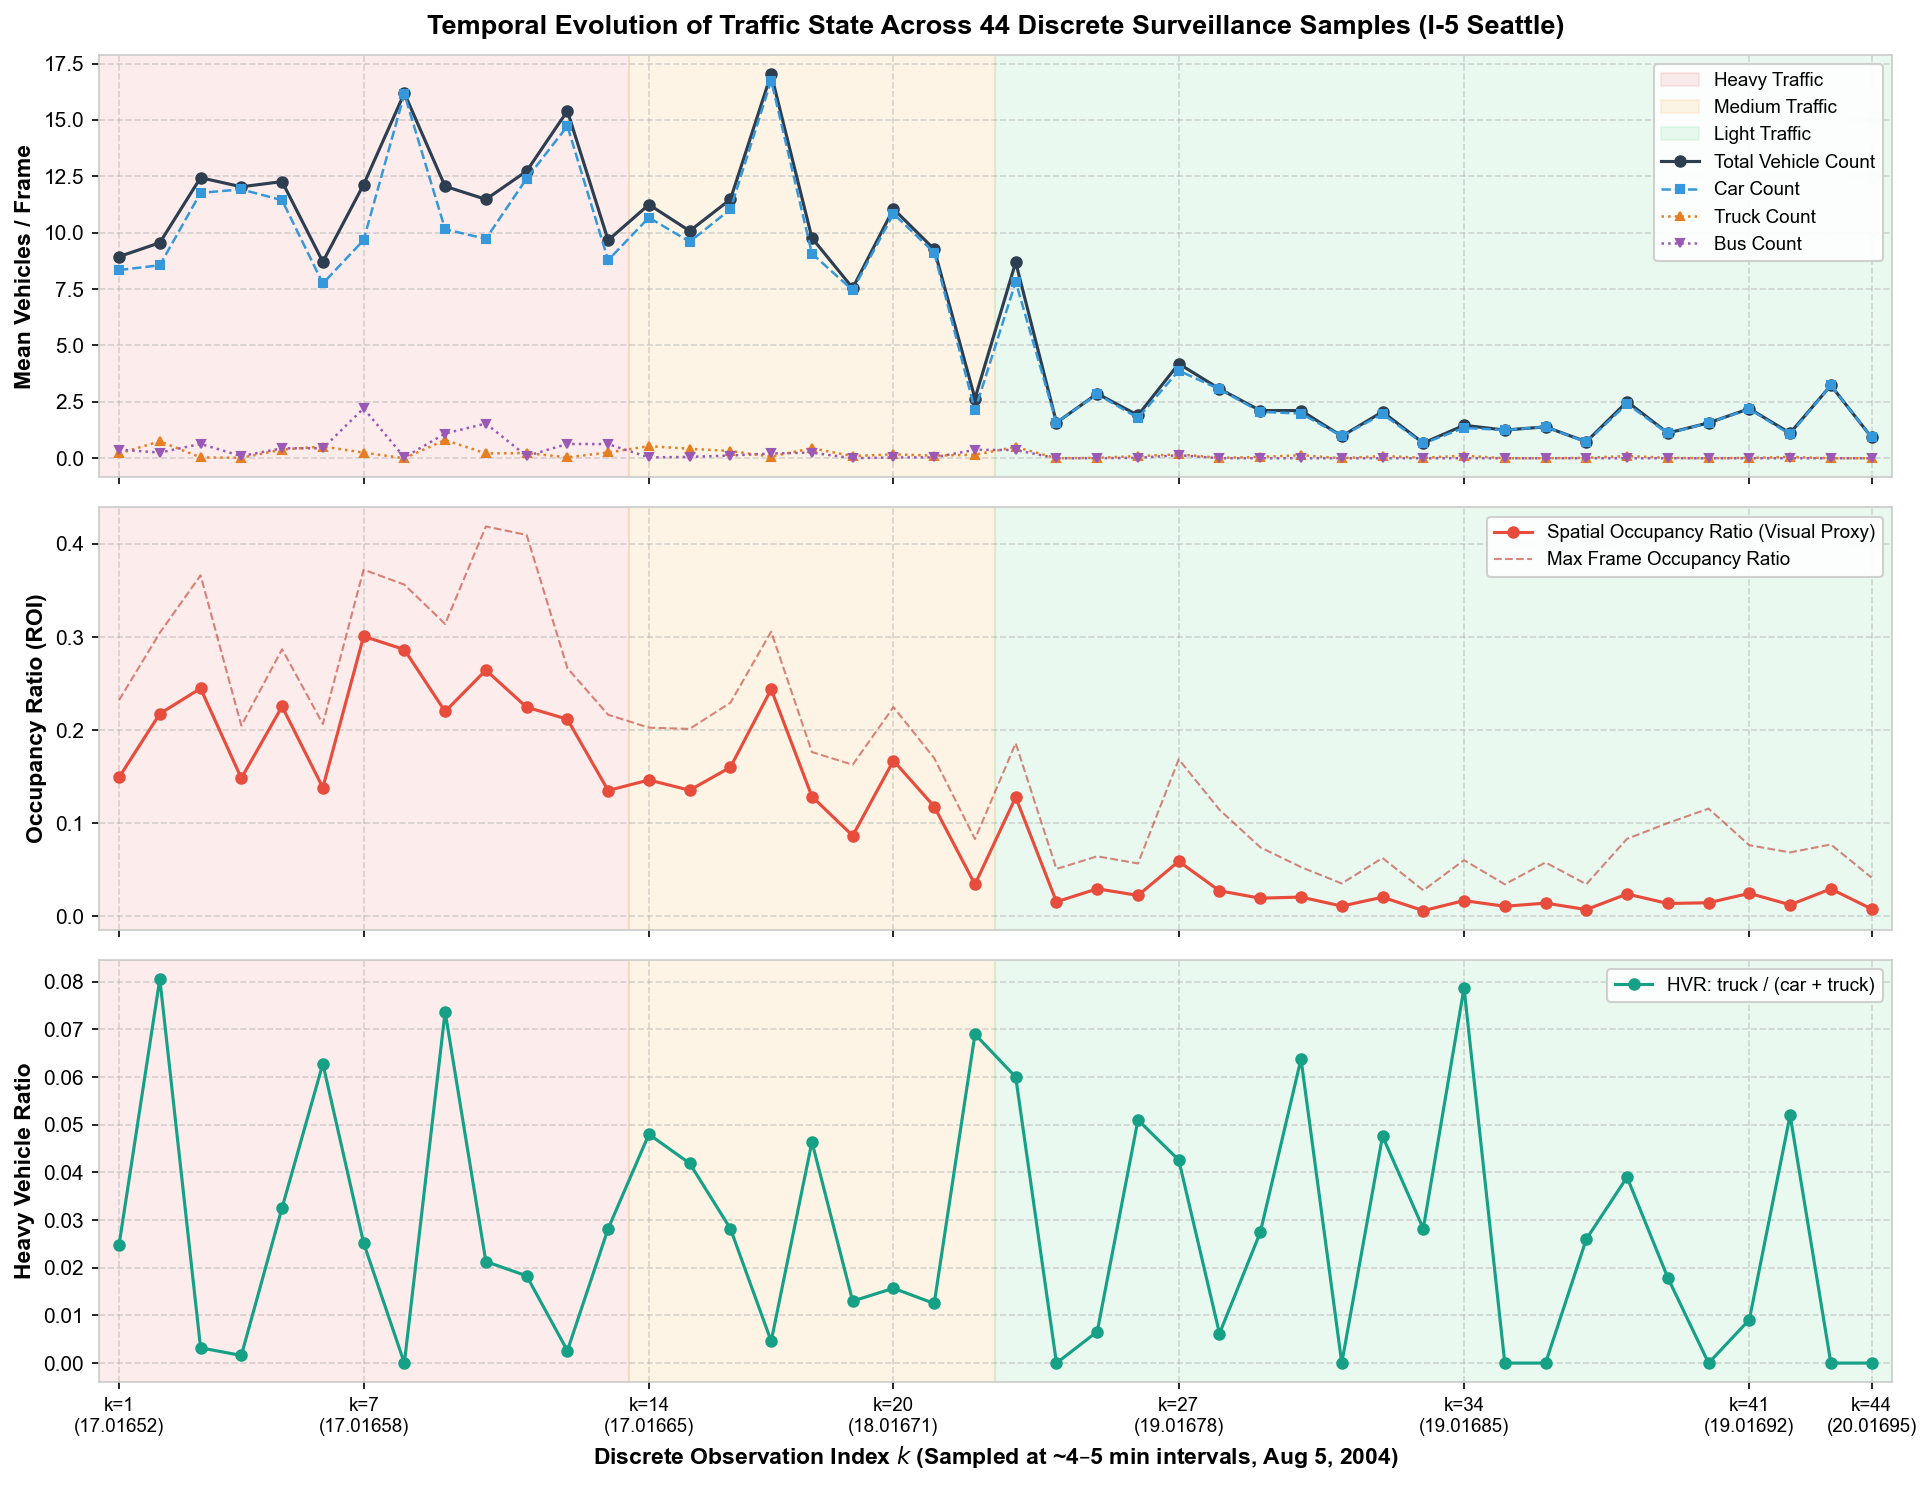

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

x = df_timeseries['observation_index']

# Define regime boundaries
heavy_end = 13.5
medium_end = 22.5
light_end = 44.5

for ax in (ax1, ax2, ax3):
    ax.axvspan(0.5, heavy_end, color='#e74c3c', alpha=0.10, label='Heavy Traffic' if ax == ax1 else "")
    ax.axvspan(heavy_end, medium_end, color='#f39c12', alpha=0.10, label='Medium Traffic' if ax == ax1 else "")
    ax.axvspan(medium_end, light_end, color='#2ecc71', alpha=0.10, label='Light Traffic' if ax == ax1 else "")

# Panel 1: Vehicle Counts & Composition
ax1.plot(x, df_timeseries['total_vehicle_count'], color='#2c3e50', marker='o', markersize=5, linewidth=1.5, label='Total Vehicle Count')
ax1.plot(x, df_timeseries['car_count'], color='#3498db', marker='s', markersize=4, linestyle='--', linewidth=1.2, label='Car Count')
ax1.plot(x, df_timeseries['truck_count'], color='#e67e22', marker='^', markersize=4, linestyle=':', linewidth=1.2, label='Truck Count')
ax1.plot(x, df_timeseries['bus_count'], color='#9b59b6', marker='v', markersize=4, linestyle=':', linewidth=1.2, label='Bus Count')
ax1.set_ylabel('Mean Vehicles / Frame', fontsize=11, fontweight='bold')
ax1.set_title('Temporal Evolution of Traffic State Across 44 Discrete Surveillance Samples (I-5 Seattle)', fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', framealpha=0.9, fontsize=9)

# Panel 2: Spatial Occupancy Ratio
ax2.plot(x, df_timeseries['occupancy_ratio'], color='#e74c3c', marker='o', markersize=5, linewidth=1.5, label='Spatial Occupancy Ratio (Visual Proxy)')
ax2.plot(x, df_timeseries['max_occupancy_ratio'], color='#c0392b', linestyle='--', alpha=0.6, linewidth=1.0, label='Max Frame Occupancy Ratio')
ax2.set_ylabel('Occupancy Ratio (ROI)', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=9)

# Panel 3: Heavy Vehicle Ratio (HVR)
ax3.plot(x, df_timeseries['HVR'], color='#16a085', marker='o', markersize=5, linewidth=1.5, label='HVR: truck / (car + truck)')
ax3.set_ylabel('Heavy Vehicle Ratio', fontsize=11, fontweight='bold')
ax3.set_xlabel('Discrete Observation Index $k$ (Sampled at ~4–5 min intervals, Aug 5, 2004)', fontsize=11, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right', framealpha=0.9, fontsize=9)

# Format x-ticks to display observation index and corresponding raw timestamp
hour_ticks = [1, 7, 14, 20, 27, 34, 41, 44]
hour_labels = [f"k={k}\n({df_timeseries.loc[k-1, 'timestamp']})" for k in hour_ticks]
ax3.set_xticks(hour_ticks)
ax3.set_xticklabels(hour_labels, fontsize=9)
ax3.set_xlim(0.5, 44.5)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_FIG_DIR, "traffic_timeseries_overview.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f"Saved overview visualization to: {fig_path}")
plt.show()

## 5. Export Final Clean Time-Series Dataset

We export the finalized time-series dataset to `outputs/tables/traffic_timeseries.csv` and verify file size, schema, and row count.

In [6]:
# Export cleaned time-series dataset
df_timeseries.to_csv(OUTPUT_CSV_PATH, index=False)

# File integrity verification
file_size_kb = os.path.getsize(OUTPUT_CSV_PATH) / 1024.0
print(f"Successfully exported time-series dataset to: {OUTPUT_CSV_PATH}")
print(f"File size on disk : {file_size_kb:.2f} KB")
print(f"Row count         : {len(df_timeseries)}")
print(f"Column count      : {df_timeseries.shape[1]}")
print(f"Exported Columns  : {list(df_timeseries.columns)}")

# Display summary statistics of the core time-series signals
print("\n=== Descriptive Statistics for Core Signals ===")
display(df_timeseries[['total_vehicle_count', 'HVR', 'occupancy_ratio', 'car_count', 'truck_count', 'bus_count']].describe().round(4))

Successfully exported time-series dataset to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
File size on disk : 5.40 KB
Row count         : 44
Column count      : 17
Exported Columns  : ['observation_index', 'clip_index', 'filename', 'date', 'timestamp', 'hour', 'seq_id', 'traffic_class', 'weather', 'valid_frames', 'total_vehicle_count', 'HVR', 'occupancy_ratio', 'car_count', 'truck_count', 'bus_count', 'max_occupancy_ratio']

=== Descriptive Statistics for Core Signals ===


,total_vehicle_count,HVR,occupancy_ratio,car_count,truck_count,bus_count
count,44.0000,44.0000,44.0000,44.0000,44.0000,44.0000
mean,6.6255,0.0275,0.1027,6.2245,0.1705,0.2305
std,5.1227,0.0247,0.0940,4.8396,0.2059,0.4410
min,0.6730,0.0000,0.0060,0.6540,0.0000,0.0000
25%,1.8222,0.0042,0.0188,1.7352,0.0190,0.0000
50%,5.8705,0.0250,0.0728,5.6680,0.0980,0.0380
75%,11.3075,0.0467,0.1619,9.8368,0.2358,0.2788
max,17.0380,0.0806,0.3008,16.7500,0.8080,2.2120


## 6. Quality Gate: Assessment for Phase 6 (Temporal EDA)

### Summary of Accomplishments (Phase 5)
1. **Faithful Temporal Structuring**:
   - Respected the empirical surveillance sampling mechanism: 44 discrete observations spaced ~4–5 minutes apart.
   - Preserved actual observation times without fabricating 30s/60s intervals or interpolating missing periods.
2. **Standardized Feature Construction**:
   - `total_vehicle_count`: macroscopic vehicle throughput per frame.
   - `HVR`: Heavy Vehicle Ratio with safe zero handling.
   - `occupancy_ratio`: spatial roadway coverage proxy.
   - Preserved all decomposed counts (`car_count`, `truck_count`, `bus_count`) and regime tags (`traffic_class`, `weather`).
3. **Automated Quality Verification**:
   - Passed all 7 rigorous integrity checks (44 rows, 0 nulls, 0 duplicate timestamps, strict monotonic chronological ordering, valid bounds on HVR and occupancy ratio).
4. **Persistent Export**:
   - Cleanly exported to `outputs/tables/traffic_timeseries.csv`.

### Formal Quality Gate Sign-Off
- **Row & Column Integrity**: **PASS** (44 rows $\times$ 17 columns)
- **Temporal Consistency**: **PASS** (Monotonically sorted by timestamp & seq_id)
- **Feature Math Validity**: **PASS** ($\text{HVR} \in [0.0, 0.0806]$, $\text{Occupancy} \in [0.006, 0.3008]$)
- **Zero Hallucinated Timestamps/Interpolations**: **PASS**

**Final Decision: APPROVED TO PROCEED TO PHASE 6 — TEMPORAL EDA.**